In [84]:
%matplotlib widget

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [86]:
DATA_DIR = Path("data")
files = sorted(DATA_DIR.glob("*.csv"))
for f in files:
    print(f.name)

00_index_suma_normal_20260313_162501.csv
01_middle_suma_normal_20260313_162555.csv
03_middle_pavan_normal_20260313_194335.csv
04_index_pavan_normal_20260313_194443.csv
05_middle_suma_hyper_20260406_162451.csv
06_middle_pavan_normal01_20260406_162928.csv
07_middle_pavan_normal_appleHR76_20260406_163030.csv
08_middle_pavan_hyper_appleHR153_143_20260406_163327.csv
09_middle_pavan_test_post_hyper_84_20260406_163527.csv
10_middle_pavan_breathing_motion_AHR_89 20260406_163735.csv
11_middle_pavan_hyper01_appleHR166_139_20260406_164521.csv


In [87]:
df = pd.read_csv(DATA_DIR / "11_middle_pavan_hyper01_appleHR166_139_20260406_164521.csv")
df['time_s'] = df['timestamp_ms'] / 1000.0
print(f"\nSamples : {len(df)}")
print(f"Duration: {df['time_s'].iloc[-1]:.1f}s")
print(f"Est. rate: {len(df) / df['time_s'].iloc[-1]:.1f} Hz")


Samples : 1830
Duration: 30.0s
Est. rate: 61.0 Hz


In [88]:
fingerONthreshold = 0.1
mask = df['time_s'] > fingerONthreshold
first_crossing = mask.idxmax() if mask.any() else None 
df_offset = df.loc[first_crossing:,:]
df_offset.reset_index()

,index,sample_index,timestamp_ms,ir,red,time_s
0,268,268,120,164875,85522,0.120
1,269,269,139,164895,85542,0.139
2,270,270,158,164914,85557,0.158
3,271,271,177,164947,85561,0.177
4,272,272,196,164954,85564,0.196
...,...,...,...,...,...,...
1557,1825,1825,29916,160022,84428,29.916
1558,1826,1826,29935,159886,84380,29.935
1559,1827,1827,29955,159830,84369,29.955
1560,1828,1828,29974,159749,84345,29.974


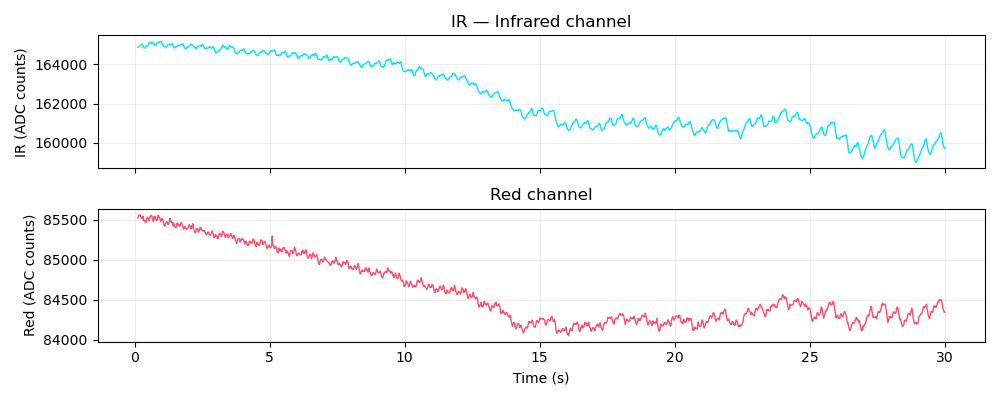

In [89]:
# ── CELL 4 — Plot raw IR and Red ──────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
 
ax1.plot(df_offset['time_s'], df_offset['ir'],  color='#00e5ff', lw=1)
ax1.set_ylabel('IR (ADC counts)')
ax1.set_title('IR — Infrared channel')
ax1.grid(True, alpha=0.2)
 
ax2.plot(df_offset['time_s'], df_offset['red'], color='#ff4d6d', lw=1)
ax2.set_ylabel('Red (ADC counts)')
ax2.set_xlabel('Time (s)')
ax2.set_title('Red channel')
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

In [90]:
from scipy.signal import butter, filtfilt

def highpass_filter(signal, cutoff_hz=0.5, fs=61.0, order=4):
    nyq = fs / 2
    b, a = butter(order, cutoff_hz / nyq, btype='high')
    return filtfilt(b, a, signal)  # zero-phase (no lag)

def bandpass_filter(signal, low=0.5, high=5.0, fs=61.0, order=4):
    nyq = fs / 2
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    return filtfilt(b, a, signal)



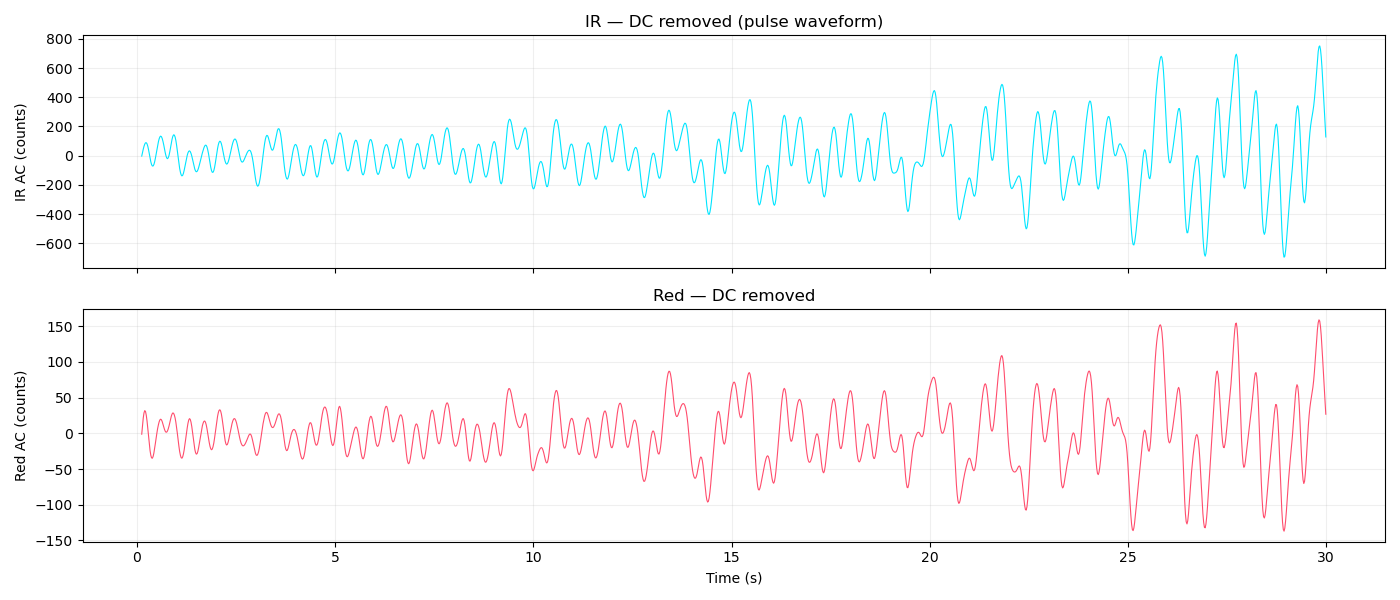

In [91]:
# ── CELL 5 — Remove DC offset (AC component only) ─────────
# The raw signal has a huge DC baseline (~155,000)
# The pulse is only the tiny ripple on top (~1,000 counts)

df_offset['ir_ac']  = bandpass_filter(df_offset['ir'],  fs=61.0)
df_offset['red_ac'] = bandpass_filter(df_offset['red'], fs=61.0)
 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
 
ax1.plot(df_offset['time_s'], df_offset['ir_ac'],  color='#00e5ff', lw=0.8)
ax1.set_ylabel('IR AC (counts)')
ax1.set_title('IR — DC removed (pulse waveform)')
ax1.grid(True, alpha=0.2)
 
ax2.plot(df_offset['time_s'], df_offset['red_ac'], color='#ff4d6d', lw=0.8)
ax2.set_ylabel('Red AC (counts)')
ax2.set_xlabel('Time (s)')
ax2.set_title('Red — DC removed')
ax2.grid(True, alpha=0.2)
 
plt.tight_layout()
plt.show()

## Beat Detection — Method 1: `scipy.find_peaks`

The simplest approach: scan the AC signal for local maxima that are tall enough and far enough apart.

**How it works:**  
`find_peaks` walks through the signal and flags any sample that is higher than both its neighbours. Two parameters do the filtering:
- `distance` — enforces a minimum gap between peaks (prevents double-detection on the same beat)
- `prominence` — measures how much a peak *stands out* from its surroundings; low-prominence bumps are noise

**Best for:** Clean, high-SNR signals with stable amplitude — exactly what you have here after bandpass filtering.  
**Watch out for:** Amplitude drift over time (a fixed `prominence` threshold may miss beats or add false ones if the signal gets weaker).

Beats detected : 66
Median IBI     : 402.0 ms
Heart rate     : 149.3 BPM


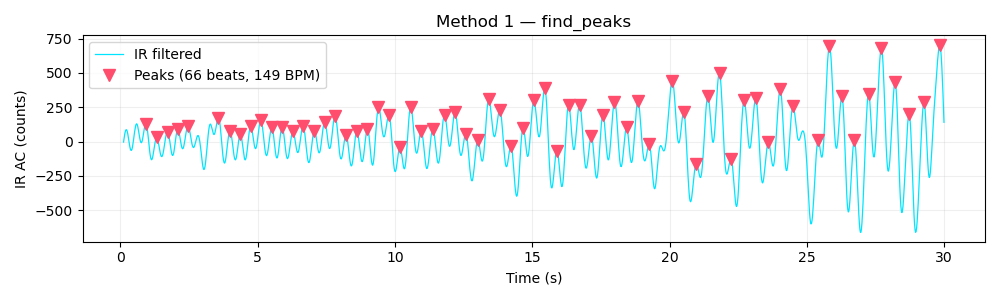

In [95]:
from scipy.signal import find_peaks, butter, filtfilt

FS = 61.0

# Bandpass filter first (0.5–4 Hz keeps 30–240 BPM, rejects noise)
def bandpass(sig, low=0.5, high=4.0, fs=FS, order=4):
    nyq = fs / 2
    b, a = butter(order, [low / nyq, high / nyq], btype='band')
    return filtfilt(b, a, sig)

ir_filt = bandpass(df_offset['ir'].values)

peaks_1, _ = find_peaks(
    ir_filt,
    # distance=int(0.4 * FS),   # min 0.4 s between beats (~150 BPM max)
    distance=int(0.3 * FS),   # min 0.4 s between beats (~150 BPM max)
    prominence=100
)

ibi_1  = np.diff(df_offset['time_s'].iloc[peaks_1].values) * 1000  # ms
bpm_1  = 60000 / np.median(ibi_1)
print(f"Beats detected : {len(peaks_1)}")
print(f"Median IBI     : {np.median(ibi_1):.1f} ms")
print(f"Heart rate     : {bpm_1:.1f} BPM")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(df_offset['time_s'], ir_filt, color='#00e5ff', lw=0.9, label='IR filtered')
ax.plot(df_offset['time_s'].iloc[peaks_1], ir_filt[peaks_1],
        'v', color='#ff4d6d', ms=8, label=f'Peaks ({len(peaks_1)} beats, {bpm_1:.0f} BPM)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('IR AC (counts)')
ax.set_title('Method 1 — find_peaks')
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## Beat Detection — Method 2: Adaptive Threshold

Instead of a single fixed prominence cutoff, the threshold *follows* the signal's local amplitude.

**How it works:**  
A rolling window (a few seconds wide) tracks the running maximum of the signal. The detection threshold is set to a fraction of that rolling max (e.g. 40%). A peak is accepted only if it rises above that local threshold. When the signal gets weaker (lighter finger pressure, slight motion), the threshold drops with it — so beats are still detected. When the signal is strong, the threshold rises — suppressing noise.

**Best for:** Recordings where amplitude drifts over time — varying finger pressure, longer sessions, or transitions between rest and movement.  
**Watch out for:** Very abrupt amplitude jumps (e.g. lifting the finger mid-recording) can cause the rolling max to overshoot and temporarily suppress valid beats.

Beats detected : 28
Median IBI     : 1053.0 ms
Heart rate     : 57.0 BPM


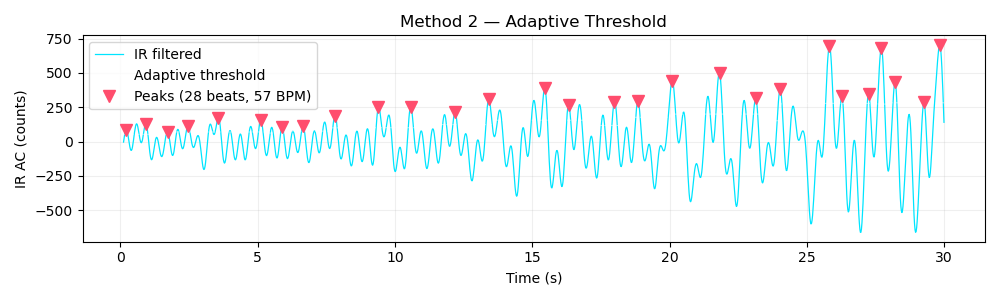

In [93]:
# Method 2 — Adaptive threshold

ir_s = pd.Series(ir_filt, index=df_offset.index)

# Rolling max over a 3-second window
win       = int(FS * 3)
roll_max  = ir_s.rolling(win, center=True, min_periods=1).max()
threshold = 0.4 * roll_max

# Candidate peaks (distance only, no fixed prominence)
candidates, _ = find_peaks(ir_filt, distance=int(0.4 * FS))

# Keep only candidates that clear the adaptive threshold
peaks_2 = np.array([p for p in candidates if ir_filt[p] > threshold.iloc[p]])

ibi_2  = np.diff(df_offset['time_s'].iloc[peaks_2].values) * 1000
bpm_2  = 60000 / np.median(ibi_2)
print(f"Beats detected : {len(peaks_2)}")
print(f"Median IBI     : {np.median(ibi_2):.1f} ms")
print(f"Heart rate     : {bpm_2:.1f} BPM")

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(df_offset['time_s'], ir_filt,      color='#00e5ff', lw=0.9, label='IR filtered')
ax.plot(df_offset['time_s'], threshold,    color='#ffffff', lw=0.8, ls='--', alpha=0.5, label='Adaptive threshold')
ax.plot(df_offset['time_s'].iloc[peaks_2], ir_filt[peaks_2],
        'v', color='#ff4d6d', ms=8, label=f'Peaks ({len(peaks_2)} beats, {bpm_2:.0f} BPM)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('IR AC (counts)')
ax.set_title('Method 2 — Adaptive Threshold')
ax.legend()
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## Beat Detection — Method 3: Continuous Wavelet Transform (CWT)

A frequency-domain approach that avoids manual threshold tuning entirely.

**How it works:**  
A wavelet is a short, oscillating waveform that looks like one heartbeat cycle. The CWT slides this wavelet across the signal at many different *scales* (widths), computing how well the signal matches the wavelet shape at each point in time. Where the correlation is strongest — across a range of scales matching expected heart rate — that's where a beat occurred. Summing the power across those scales gives a clean 1D "beat energy" signal that is easy to peak-detect on.

**Best for:** Noisy or low-SNR signals, irregular rhythms, or when you want to avoid manual threshold tuning. Robust because it matches pulse *shape*, not just amplitude.  
**Watch out for:** Slower than the other methods; more complex to reason about when things go wrong. Scale range must match your expected heart rate range.

Beats detected : 33
Median IBI     : 861.0 ms
Heart rate     : 69.7 BPM


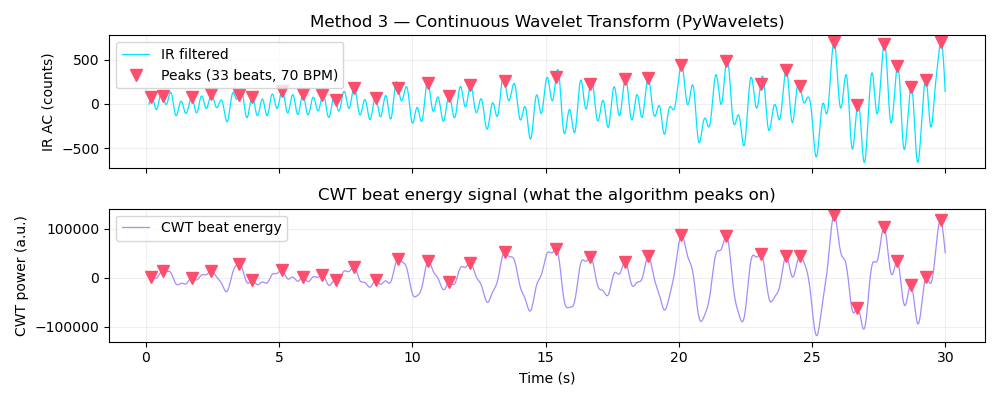

In [94]:
import pywt

# pywt.cwt expects scales in terms of the wavelet's characteristic frequency
# For the 'mexh' (Mexican hat) wavelet, central frequency ~0.25
# scale = (central_freq * FS) / beat_freq_hz
# Beat freq range: 40 BPM = 0.67 Hz, 180 BPM = 3.0 Hz
central_freq = pywt.central_frequency('mexh')
scale_min = central_freq * FS / 3.0   # 180 BPM
scale_max = central_freq * FS / 0.67  # 40  BPM
scales    = np.linspace(scale_min, scale_max, 60)

cwt_matrix, freqs = pywt.cwt(ir_filt, scales, 'mexh', sampling_period=1/FS)
beat_energy = cwt_matrix.sum(axis=0)   # sum power across all scales

peaks_3, _ = find_peaks(beat_energy, distance=int(0.4 * FS))

ibi_3  = np.diff(df_offset['time_s'].iloc[peaks_3].values) * 1000
bpm_3  = 60000 / np.median(ibi_3)
print(f"Beats detected : {len(peaks_3)}")
print(f"Median IBI     : {np.median(ibi_3):.1f} ms")
print(f"Heart rate     : {bpm_3:.1f} BPM")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 4), sharex=True)

ax1.plot(df_offset['time_s'], ir_filt, color='#00e5ff', lw=0.9, label='IR filtered')
ax1.plot(df_offset['time_s'].iloc[peaks_3], ir_filt[peaks_3],
         'v', color='#ff4d6d', ms=8, label=f'Peaks ({len(peaks_3)} beats, {bpm_3:.0f} BPM)')
ax1.set_ylabel('IR AC (counts)')
ax1.set_title('Method 3 — Continuous Wavelet Transform (PyWavelets)')
ax1.legend()
ax1.grid(True, alpha=0.2)

ax2.plot(df_offset['time_s'], beat_energy, color='#a78bfa', lw=0.9, label='CWT beat energy')
ax2.plot(df_offset['time_s'].iloc[peaks_3], beat_energy[peaks_3],
         'v', color='#ff4d6d', ms=8)
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('CWT power (a.u.)')
ax2.set_title('CWT beat energy signal (what the algorithm peaks on)')
ax2.legend()
ax2.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()